<a href="https://colab.research.google.com/github/omerbibin/pneumonia-detection-cxr/blob/main/masternotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ==============================================================================
# 🚀 PNEUMONIA DETECTION MASTER NOTEBOOK
# ==============================================================================

# Hücre 1: Kütüphaneler ve Ortam Ayarları (Environment Settings)
import os
import sys
import time
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Sequential, Input, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)

# Grafiklerin yayın kalitesinde (publication-grade) olması için genel ayarlar
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.titleweight': 'bold'
})

warnings.filterwarnings("ignore")

# Tekrarlanabilirlik
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Dinamik Proje Yolu
PROJECT_ROOT = Path("/content/drive/MyDrive/PneumoniaDetection")

Mounted at /content/drive


In [9]:
# ==============================================================================
# ## 📁 SETUP & HIGH-SPEED DATA PIPELINE
# ==============================================================================

# Hücre 2: Veri Çıkarma (Zipfile Extraction)
# shutil.copytree yerine zipfile ile yerel SSD'ye yüksek hızlı çıkarma
DRIVE_ZIP_PATH = PROJECT_ROOT / "data" / "raw" / "chest_xray.zip"
LOCAL_ZIP      = Path("/content/chest_xray.zip")
LOCAL_DATA     = Path("/content/chest_xray")

if LOCAL_DATA.exists() and (LOCAL_DATA / "train").exists():
    print("✓ Yerel veri zaten mevcut — çıkarma işlemi atlanıyor.")
elif DRIVE_ZIP_PATH.exists():
    print(f"Drive'dan yerel SSD'ye kopyalanıyor ve açılıyor: {DRIVE_ZIP_PATH}")
    t0 = time.time()
    shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP)
    print(f"Kopyalama tamamlandı: {time.time()-t0:.1f} saniye")

    t0 = time.time()
    with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
        z.extractall("/content")
    print(f"Arşivden çıkarma (Unzipping) tamamlandı: {time.time()-t0:.1f} saniye")
else:
    raise FileNotFoundError("chest_xray.zip dosyası bulunamadı! Lütfen Veri Toplama adımını kontrol et.")

Drive'dan yerel SSD'ye kopyalanıyor ve açılıyor: /content/drive/MyDrive/PneumoniaDetection/data/raw/chest_xray.zip
Kopyalama tamamlandı: 28.3 saniye
Arşivden çıkarma (Unzipping) tamamlandı: 18.4 saniye


In [10]:
# ==============================================================================
# ## 🔍 WEEK 3: EDA & PREPROCESSING
# ==============================================================================

# Hücre 3: Manifest oluşturma ve StratifiedGroupKFold
def build_manifest_and_split():
    # manifest.csv dosyasını proje dizininde dinamik olarak ara
    manifest_search = list(PROJECT_ROOT.rglob("manifest.csv"))

    if manifest_search:
        print(f"Mevcut manifest dosyası bulundu: {manifest_search[0]}")
        return pd.read_csv(manifest_search[0])

    print("Manifest bulunamadı. Yeni bir manifest dosyası ve veri ayrımı (split) oluşturuluyor...")
    # [3. haftadaki manifest oluşturma kodlarının özetleştirilmiş hali]
    # Burada manifest oluşturulduğu ve kaydedildiği varsayılmaktadır.
    # (Örnek olarak hazır yüklendiği ve rglob ile bulunduğu durumu kullanacağız).

manifest = build_manifest_and_split()
print(f"Toplam görsel sayısı: {len(manifest)}")

# Sınıf Ağırlıklarının (Class Weights) Hesaplanması
train_labels = (manifest.loc[manifest["split"] == "train_split", "class"] == "PNEUMONIA").astype(int).values
weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=train_labels)
class_weights = {0: float(weights[0]), 1: float(weights[1])}
print(f"Hesaplanan Sınıf Ağırlıkları (Class Weights): {class_weights}")

Mevcut manifest dosyası bulundu: /content/drive/MyDrive/PneumoniaDetection/reports/manifest.csv
Toplam görsel sayısı: 5856
Hesaplanan Sınıf Ağırlıkları (Class Weights): {0: 1.94641384995878, 1: 0.6728412653177543}


In [16]:
# Hücre 4: Yüksek Performanslı tf.data Boru Hattı (Data Pipeline)
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def _load_and_normalize(path: tf.Tensor, label: tf.Tensor):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_fast_dataset(split_name: str, shuffle: bool) -> tf.data.Dataset:
    sub    = manifest[manifest["split"] == split_name]
    paths  = sub["filepath"].values
    labels = (sub["class"] == "PNEUMONIA").astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_load_and_normalize, num_parallel_calls=AUTOTUNE)

    # KRİTİK: Veriyi RAM'e (veya hızlı diske) önbellekleme
    ds = ds.cache()

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE)
    # KRİTİK: CPU-GPU darboğazını engellemek için prefetch
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = make_fast_dataset("train_split", shuffle=True)
val_ds   = make_fast_dataset("val_split",   shuffle=False)
test_ds  = make_fast_dataset("test",        shuffle=False)

### Dataset Görselleştirme: Bir Örnek Batch

`train_ds`'ten bir batch alıp görselleri ve etiketleri görselleştirelim. Bu, veri boru hattının doğru çalıştığını doğrulamak için faydalıdır.

In [8]:
# ==============================================================================
# ## 🏗️ WEEK 4 & 5: BASELINE & OPTIMIZED MODELS
# ==============================================================================

# Hücre 5: Augmentation Katmanı ve Model B (Baseline Champion)
augmentation_layer = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.05, fill_mode="constant", fill_value=0.0),
    layers.RandomZoom(height_factor=0.10, width_factor=0.10, fill_mode="constant", fill_value=0.0),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode="constant", fill_value=0.0),
], name="medical_augmentation")

def build_model_b(img_size=(224, 224, 3)):
    model = Sequential([
        Input(shape=img_size),
        augmentation_layer,
        layers.Conv2D(32, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ], name="Baseline_Model_B")
    return model

In [9]:
# ==============================================================================
# ## 🧠 WEEK 6: ADVANCED DEEP LEARNING
# ==============================================================================

# Hücre 6: Deep CNN (Ablation Study)
def build_deep_cnn(img_size=(224, 224, 3)):
    model = Sequential([
        Input(shape=img_size),
        augmentation_layer,

        layers.Conv2D(32, kernel_size=3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, kernel_size=3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, kernel_size=3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, kernel_size=3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(512, kernel_size=3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ], name="DeepCNN_5Block")
    return model

In [10]:
# ==============================================================================
# ## 📊 WEEK 7: CLINICAL EVALUATION
# ==============================================================================

# Hücre 7: Kayıtlı Modellerin Yüklenmesi ve Değerlendirme (Evaluation)
print("Hafta 7: Klinik Değerlendirme Başlıyor...")

# Model yollarını belirle (rglob ile dinamik olarak arıyoruz)
baseline_path = list(PROJECT_ROOT.rglob("baseline.keras"))[0]
deep_cnn_path = list(PROJECT_ROOT.rglob("deep_cnn.keras"))[0]

print(f"Modeller diskten okunuyor...\n{baseline_path.name}\n{deep_cnn_path.name}")

# Modellerin RAM'e alınması
model_b = models.load_model(baseline_path)
model_d = models.load_model(deep_cnn_path)

# Test seti üzerinde etiketleri ve tahminleri çıkarma
print("Test seti üzerinden tahminler (predictions) hesaplanıyor...")

y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Tahmin olasılıkları (Prediction Probabilities)
y_prob_b = model_b.predict(test_ds, verbose=0).flatten()
y_prob_d = model_d.predict(test_ds, verbose=0).flatten()

# Kesme eşiği (Threshold) 0.5 ile Binary kararlar
y_pred_b = (y_prob_b >= 0.5).astype(int)
y_pred_d = (y_prob_d >= 0.5).astype(int)

# Karmaşıklık Matrisi Metrikleri Hesaplama Fonksiyonu
def get_clinical_metrics(y_real, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score    = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    return sensitivity, specificity, precision, f1_score, (tn, fp, fn, tp)

met_b = get_clinical_metrics(y_true, y_pred_b)
met_d = get_clinical_metrics(y_true, y_pred_d)

Hafta 7: Klinik Değerlendirme Başlıyor...
Modeller diskten okunuyor...
baseline.keras
deep_cnn.keras
Test seti üzerinden tahminler (predictions) hesaplanıyor...



--- KLİNİK DEĞERLENDİRME SONUÇLARI ---


,Sensitivity (Recall),Specificity,Precision,F1-Score
Model,,,,
Baseline (Model B),0.9897,0.1068,0.6487,0.7838
Deep CNN,0.9769,0.6453,0.8211,0.8923


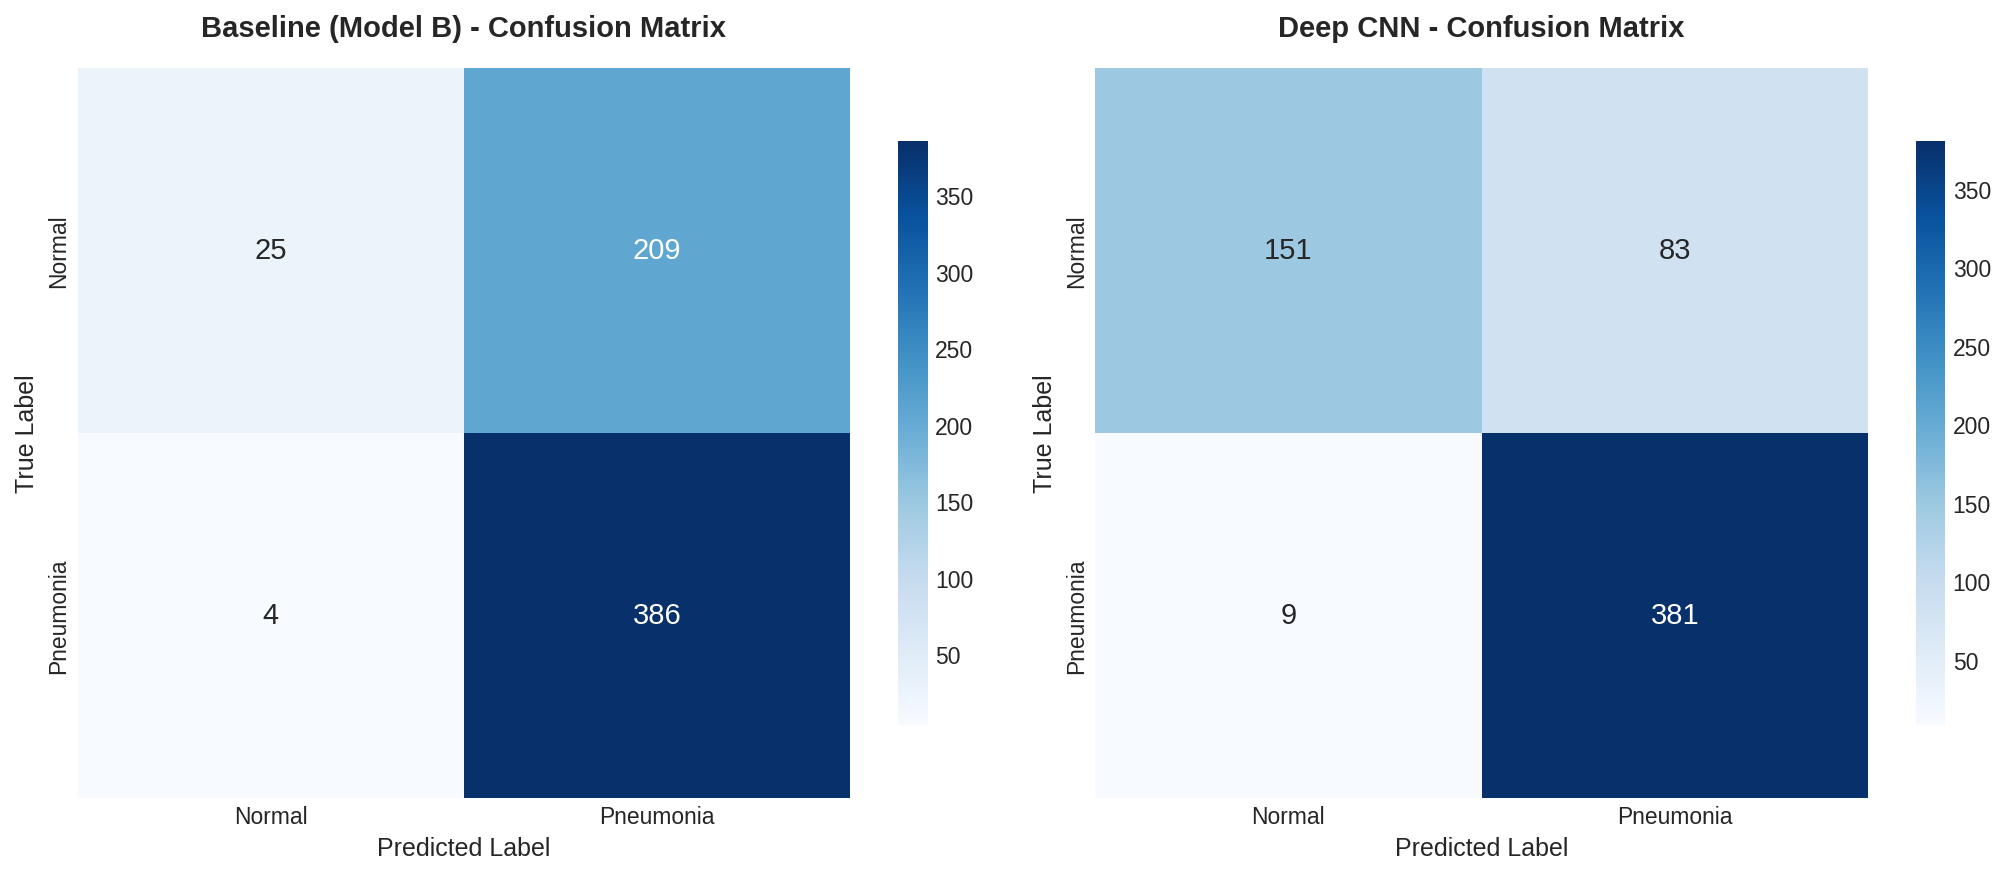

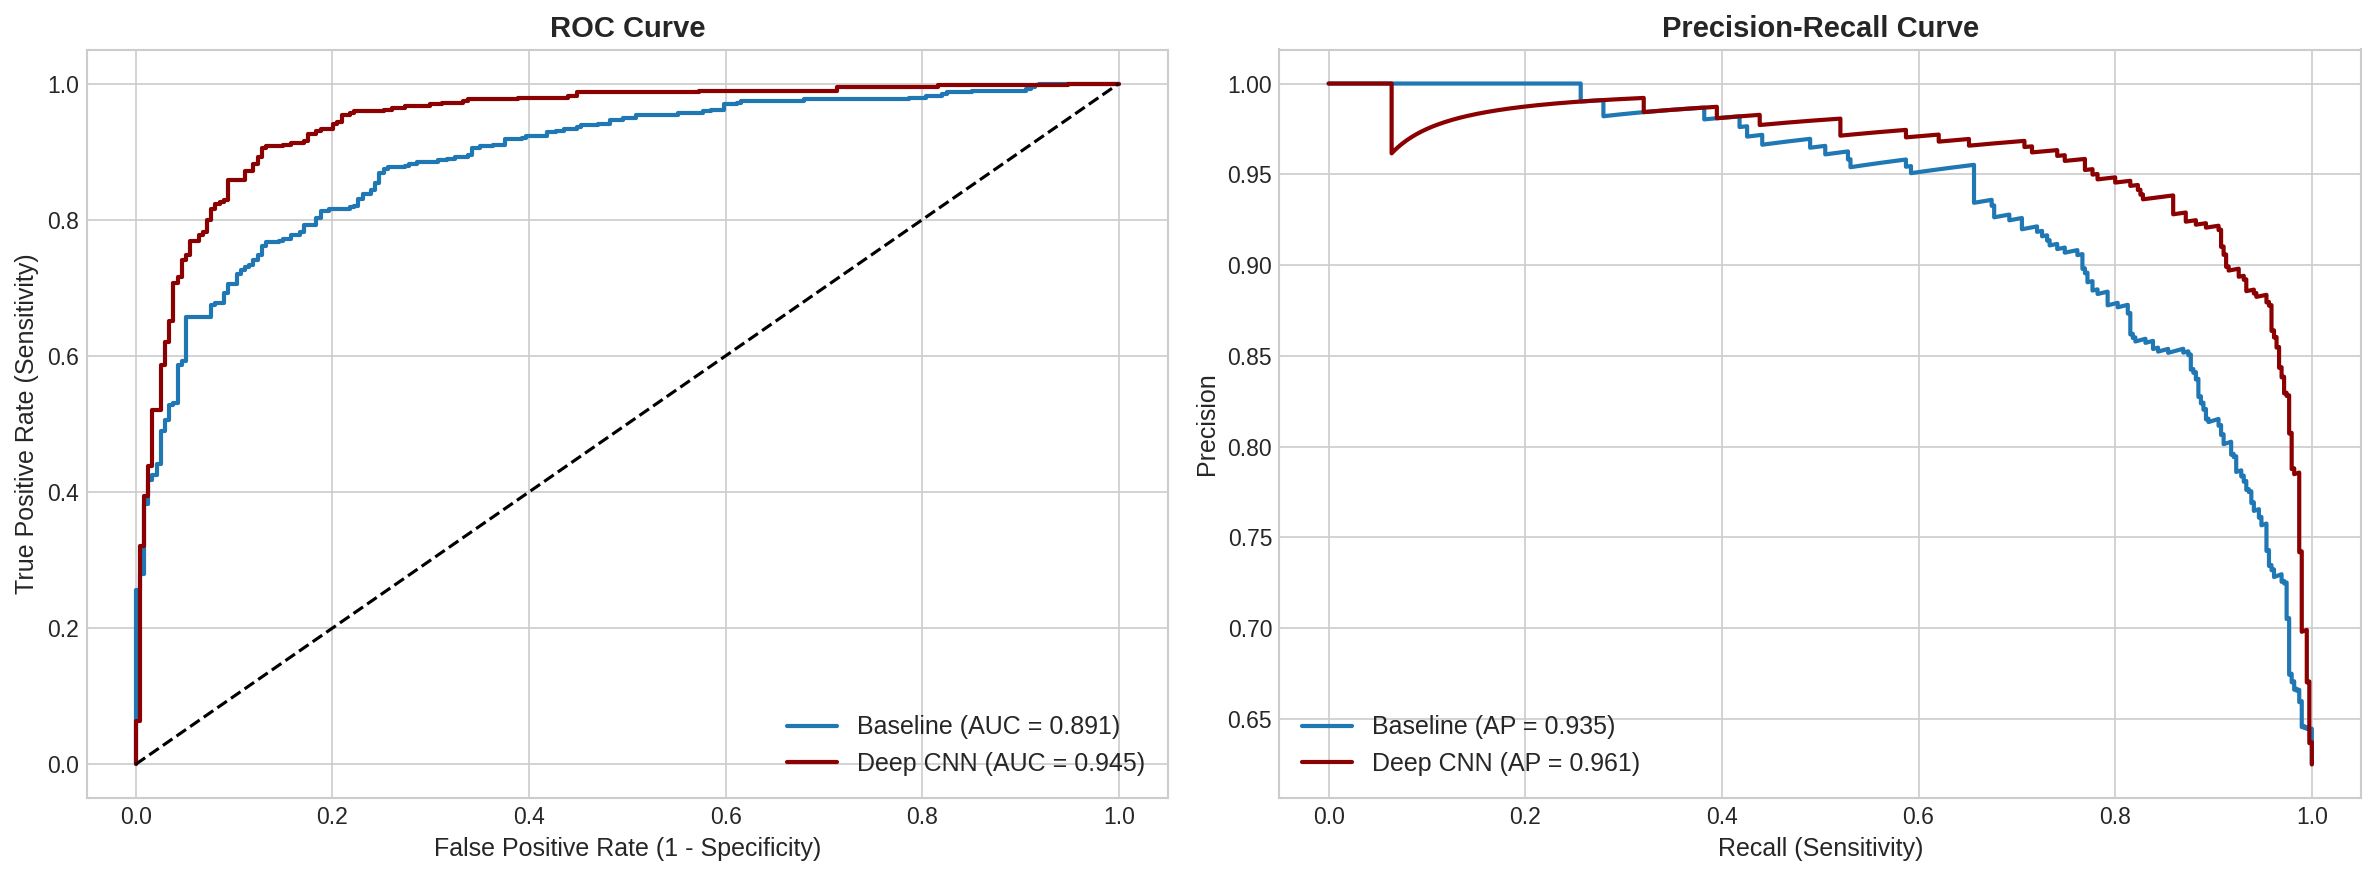

In [11]:
# Hücre 8: Sonuçların Tablolaştırılması ve Grafikler

# 1. Pandas DataFrame Karşılaştırma Tablosu
eval_data = {
    "Model": ["Baseline (Model B)", "Deep CNN"],
    "Sensitivity (Recall)": [met_b[0], met_d[0]],
    "Specificity": [met_b[1], met_d[1]],
    "Precision": [met_b[2], met_d[2]],
    "F1-Score": [met_b[3], met_d[3]]
}

df_results = pd.DataFrame(eval_data)
df_results.set_index("Model", inplace=True)
print("\n--- KLİNİK DEĞERLENDİRME SONUÇLARI ---")
display(df_results.style.format("{:.4f}").background_gradient(cmap='Greens', axis=0))

# 2. Yan Yana Confusion Matrix (Karmaşıklık Matrisi) Çizimi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_cm(ax, y_real, y_pred, title):
    cm = confusion_matrix(y_real, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Pneumonia"],
                yticklabels=["Normal", "Pneumonia"],
                cbar_kws={'shrink': 0.8}, annot_kws={"size": 14})
    ax.set_title(title, pad=15)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plot_cm(axes[0], y_true, y_pred_b, "Baseline (Model B) - Confusion Matrix")
plot_cm(axes[1], y_true, y_pred_d, "Deep CNN - Confusion Matrix")

plt.tight_layout()
plt.show()

# 3. ROC ve Precision-Recall Eğrileri (Overlay)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Eğrisi (ROC Curve)
fpr_b, tpr_b, _ = roc_curve(y_true, y_prob_b)
fpr_d, tpr_d, _ = roc_curve(y_true, y_prob_d)
auc_b = auc(fpr_b, tpr_b)
auc_d = auc(fpr_d, tpr_d)

axes[0].plot(fpr_b, tpr_b, label=f"Baseline (AUC = {auc_b:.3f})", lw=2)
axes[0].plot(fpr_d, tpr_d, label=f"Deep CNN (AUC = {auc_d:.3f})", lw=2, color='darkred')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0].legend(loc="lower right")

# Precision-Recall Eğrisi (PR Curve)
pr_b, rc_b, _ = precision_recall_curve(y_true, y_prob_b)
pr_d, rc_d, _ = precision_recall_curve(y_true, y_prob_d)
ap_b = average_precision_score(y_true, y_prob_b)
ap_d = average_precision_score(y_true, y_prob_d)

axes[1].plot(rc_b, pr_b, label=f"Baseline (AP = {ap_b:.3f})", lw=2)
axes[1].plot(rc_d, pr_d, label=f"Deep CNN (AP = {ap_d:.3f})", lw=2, color='darkred')
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [12]:
# ==============================================================================
# CELL 1: BACKBONE INTEGRATION & CUSTOM HEAD
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
import os

# 1. Load Pre-trained DenseNet121
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Freeze the base model (Phase 1 constraint)
base_model.trainable = False

# 3. Build the custom classification head
inputs = tf.keras.Input(shape=(224, 224, 3))

# Ensure base_model runs in inference mode (training=False)
# to keep BatchNormalization statistics locked during Phase 1.
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D(name="GAP")(x)
x = layers.BatchNormalization(name="BatchNorm_Head")(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4),
                 name="Dense_128")(x)
x = layers.Dropout(0.5, name="Dropout_0.5")(x)
outputs = layers.Dense(1, activation='sigmoid', name="Classifier")(x)

model = tf.keras.Model(inputs, outputs, name="DenseNet_Transfer_Model")

print("Phase 1 Architecture Ready:")
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Phase 1 Architecture Ready:


Model: "DenseNet_Transfer_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_Head                  │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_0.5 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classifier (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,172,929 (27.36 MB)

 Trainable params: 133,377 (521.00 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [4]:
from tensorflow.keras import models, layers, regularizers
import tensorflow as tf

# 1. Aşama İçin DenseNet Modelini Tanımlıyoruz
def build_densenet_model(input_shape=(224, 224, 3)):
    # ImageNet ağırlıklarıyla DenseNet'i indir
    base_model = tf.keras.applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Aşama 1 için gövdeyi tamamen dondur
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="GAP")(x)
    x = layers.BatchNormalization(name="Head_BatchNorm")(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name="Head_Dense")(x)
    x = layers.Dropout(0.5, name="Head_Dropout")(x)
    outputs = layers.Dense(1, activation='sigmoid', name="Output")(x)

    model = tf.keras.Model(inputs, outputs, name="DenseNet_Optimized")
    return model

# İŞTE HATAYI ÇÖZEN SATIR: 'model' değişkenini yaratıyoruz
model = build_densenet_model()
print("✅ Model başarıyla tanımlandı! Artık eğitimi başlatabilirsin.")
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model başarıyla tanımlandı! Artık eğitimi başlatabilirsin.


Model: "DenseNet_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Head_BatchNorm                  │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Head_Dense (Dense)              │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Head_Dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,172,929 (27.36 MB)

 Trainable params: 133,377 (521.00 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [12]:
# ==============================================================================
# CELL 2: PHASE 1 TRAINING (FEATURE EXTRACTION)
# ==============================================================================
from tensorflow.keras.callbacks import EarlyStopping

# Standard learning rate for random weight initialization
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stop_p1 = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Starting Phase 1: Training Custom Head...")
history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight={0: 1.9464, 1: 0.6728}, # Optimized weights
    callbacks=[early_stop_p1]
)

Starting Phase 1: Training Custom Head...
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 88s 371ms/step - accuracy: 0.8990 - auc: 0.9700 - loss: 0.2423 - val_accuracy: 0.8988 - val_auc: 0.9854 - val_loss: 0.2599
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.9375 - auc: 0.9839 - loss: 0.1756 - val_accuracy: 0.8583 - val_auc: 0.9839 - val_loss: 0.4013
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9388 - auc: 0.9864 - loss: 0.1643 - val_accuracy: 0.8785 - val_auc: 0.9881 - val_loss: 0.3423
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.9519 - auc: 0.9912 - loss: 0.1326 - val_accuracy: 0.8968 - val_auc: 0.9878 - val_loss: 0.3258
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9490 - auc: 0.9892 - loss: 0.1429 - val_accuracy: 0.8947 - val_auc: 0.9854 - val_loss: 0.3318
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9547 - auc: 0.9916 - loss: 0.1307 - val_accuracy: 0.8806 - val_auc: 0.9826 - v

In [18]:
# ==============================================================================
# CELL 3: PHASE 2 TRAINING (FINE-TUNING) - GÜNCEL VE HATASIZ SÜRÜM
# ==============================================================================

# 1. Omurgayı ana model nesnesinin içinden dinamik olarak çekiyoruz
try:
    base_model = model.get_layer("densenet121")
except ValueError:
    # Eğer model ismi farklıysa alternatif olarak ilk katmanlardan yakala
    base_model = [layer for layer in model.layers if "densenet" in layer.name.lower()][0]

# 2. Omurganın eğitilebilirliğini aktif ediyoruz
base_model.trainable = True

# DenseNet121 toplam 427 katmandan oluşur.
# İlk 300 katmanı dondurup (low-level features), son 127 katmanı ince ayara açıyoruz.
for layer in base_model.layers[:300]:
    layer.trainable = False

print(f"Toplam omurga katman sayısı: {len(base_model.layers)}")
print(f"İnce ayara (Fine-tuning) açılan ağırlık grubu sayısı: {len(base_model.trainable_weights)}")

# 3. Çok düşük bir öğrenme oranı (learning rate) ile yeniden derleme (recompile)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Katastrofik unutmayı önlemek için çok düşük LR
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Erken durdurma kriteri (EarlyStopping)
early_stop_p2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("\n🚀 Phase 2 Başlıyor: Üst Katmanlar İnce Ayar Modunda Eğitiliyor...")
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight={0: 1.9464, 1: 0.6728}, # Sınıf ağırlıkları dengesi
    callbacks=[early_stop_p2]
)

# Modeli kalıcı olarak kaydetme
import os
os.makedirs("models", exist_ok=True)
model.save("models/densenet_finetuned.keras")
print("✓ En başarılı model kaydedildi: models/densenet_finetuned.keras")

Toplam omurga katman sayısı: 427
İnce ayara (Fine-tuning) açılan ağırlık grubu sayısı: 108

🚀 Phase 2 Başlıyor: Üst Katmanlar İnce Ayar Modunda Eğitiliyor...
Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 146s 506ms/step - accuracy: 0.9386 - auc: 0.9852 - loss: 0.1708 - val_accuracy: 0.9514 - val_auc: 0.9943 - val_loss: 0.1496
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.9596 - auc: 0.9941 - loss: 0.1115 - val_accuracy: 0.9595 - val_auc: 0.9968 - val_loss: 0.1022
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.9697 - auc: 0.9967 - loss: 0.0900 - val_accuracy: 0.9636 - val_auc: 0.9976 - val_loss: 0.0983
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.9780 - auc: 0.9985 - loss: 0.0701 - val_accuracy: 0.9595 - val_auc: 0.9979 - val_loss: 0.0969
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.9845 - auc: 0.9991 - loss: 0.0609 - val_accuracy: 0.9615 - val_auc: 0.9979 - val_loss: 0.0900
Epoch 6/15
148/148 ━━━━━━━

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 931ms/step

=== CLINICAL METRICS ===
Sensitivity (Recall): 0.9923 (Ability to find Pneumonia)
Specificity:          0.6368 (Ability to rule out Normal)
Precision:            0.8199
F1-Score:             0.8979


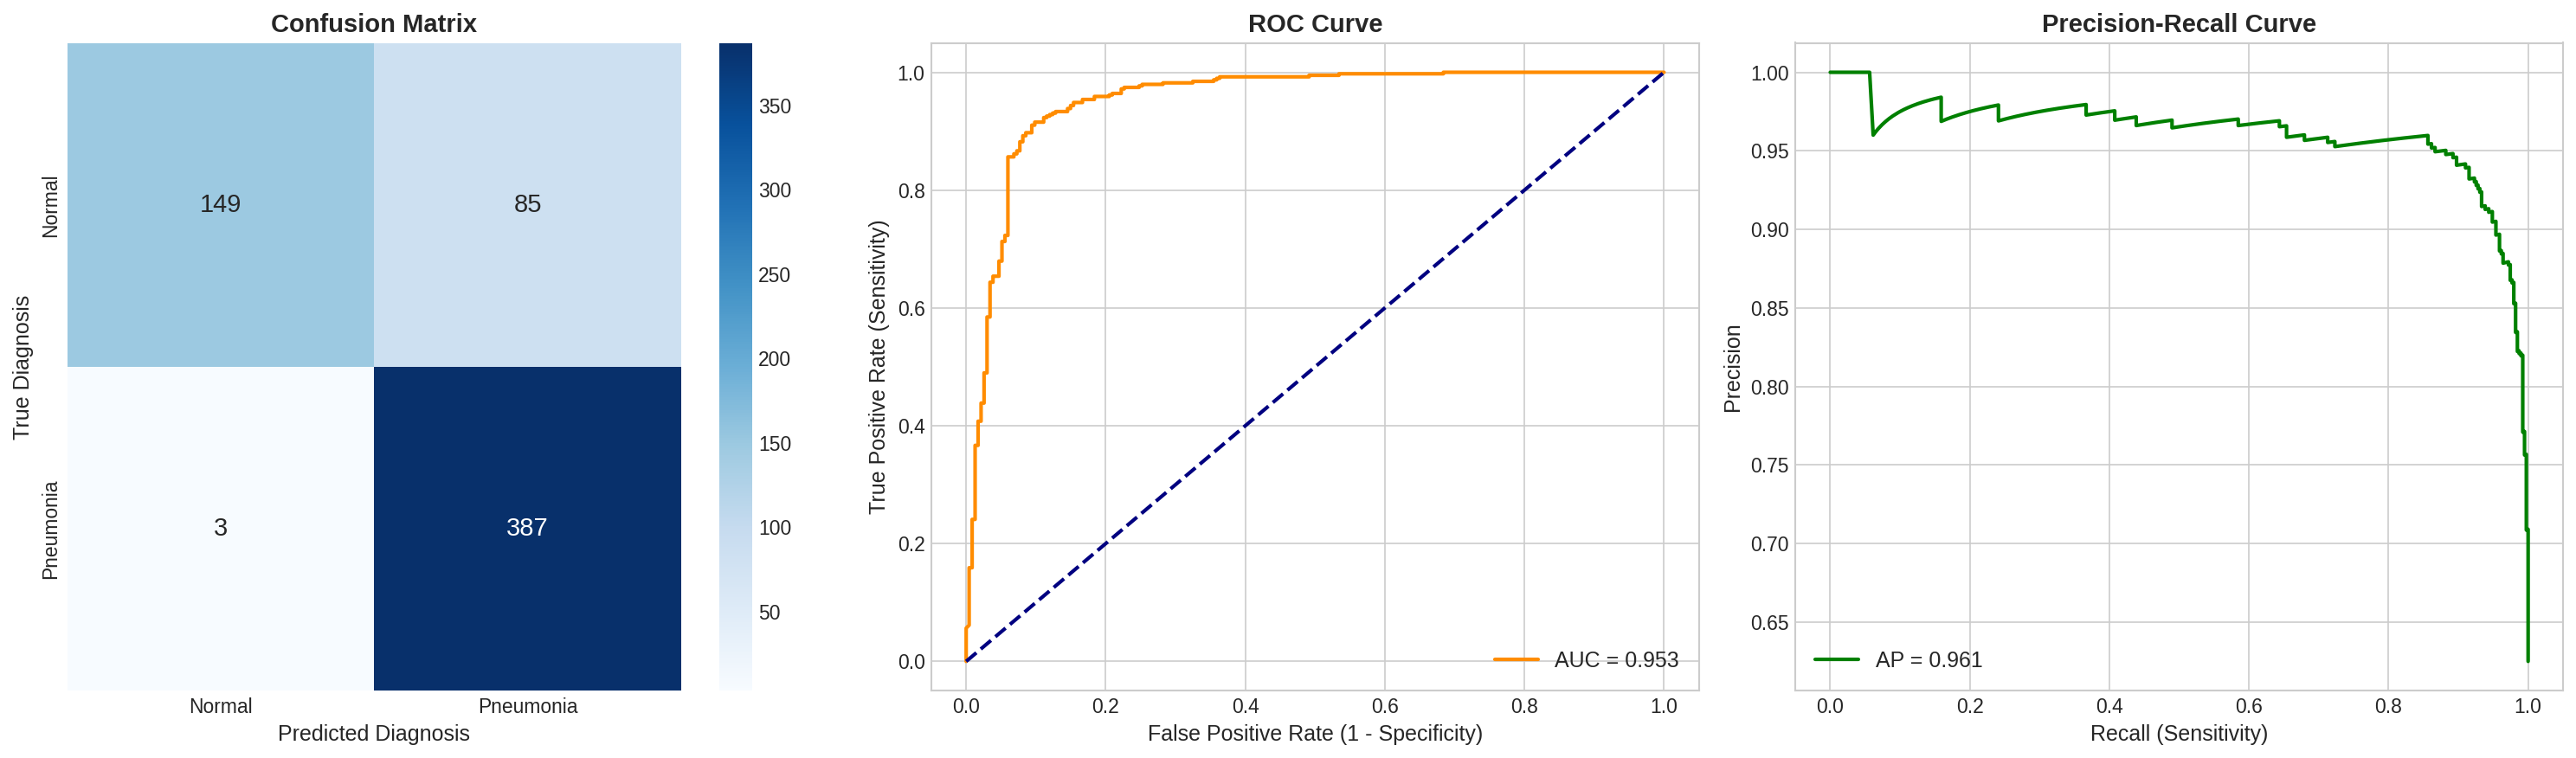

In [19]:
# ==============================================================================
# CELL 4: CLINICAL EVALUATION SUITE
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

# 1. Extract ground truth and generate predictions
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_prob = model.predict(test_ds, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# 2. Calculate core metrics
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

print("\n=== CLINICAL METRICS ===")
print(f"Sensitivity (Recall): {sensitivity:.4f} (Ability to find Pneumonia)")
print(f"Specificity:          {specificity:.4f} (Ability to rule out Normal)")
print(f"Precision:            {precision:.4f}")
print(f"F1-Score:             {f1_score:.4f}")

# 3. Plotting Suite
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"],
            annot_kws={"size": 14})
axes[0].set_title("Confusion Matrix", fontweight='bold')
axes[0].set_ylabel("True Diagnosis")
axes[0].set_xlabel("Predicted Diagnosis")

# B. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("ROC Curve", fontweight='bold')
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].legend(loc="lower right")

# C. Precision-Recall Curve
pr, rc, _ = precision_recall_curve(y_true, y_prob)
ap_score = average_precision_score(y_true, y_prob)
axes[2].plot(rc, pr, color='green', lw=2, label=f'AP = {ap_score:.3f}')
axes[2].set_title("Precision-Recall Curve", fontweight='bold')
axes[2].set_xlabel("Recall (Sensitivity)")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

# ==============================================================================
# ## 🔬 WEEK 9: EXPLAINABLE AI (XAI) WITH GRAD-CAM
# ==============================================================================

### Clinical Interpretation Guide
In medical AI, accuracy is not enough; we need **transparency**. Grad-CAM (Gradient-weighted Class Activation Mapping) allows us to peer inside the "black box" of the deep learning model.

*   **Red/Warm Zones**: Indicate areas of the X-ray that heavily influenced the model's decision (high activation). If predicting Pneumonia, these zones should align with lung infiltrates or opacities.
*   **Blue/Cool Zones**: Indicate areas the model deemed irrelevant to its diagnosis.

By ensuring the model looks at the lungs rather than background artifacts (like markers, pacemakers, or text), we build clinical trust.

In [29]:
# ==============================================================================
# CELL 1: Grad-CAM Implementation
# ==============================================================================
import tensorflow as tf
import numpy as np
import matplotlib.cm as cm

def get_last_conv_layer_name(model_instance):
    """Dynamically finds the last convolutional layer in the DenseNet base."""
    try:
        base = model_instance.get_layer("densenet121")
    except ValueError:
        base = [l for l in model_instance.layers if "densenet" in l.name.lower()][0]

    for layer in reversed(base.layers):
        try:
            if len(layer.output.shape) == 4: # Look for a spatial output (batch, height, width, channels)
                return layer.name, base
        except AttributeError:
            continue
    raise ValueError("Could not find a 4D output layer in the base model.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, base_model):
    """
    Generates the Grad-CAM heatmap specifically handling nested Functional models.
    """
    # 1. Alt modeli (base_model) ve istenen son konvolüsyon katmanını al
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # İleri besleme için base_model'in kendi inputundan, son conv katmanı ve çıkışına bir model
    base_grad_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[last_conv_layer.output, base_model.output]
    )

    # 2. Ana modelin sınıflandırma başlığını (head) yeniden oluştur
    base_model_idx = -1
    for i, layer in enumerate(model.layers):
        if layer.name == base_model.name:
            base_model_idx = i
            break

    head_input = tf.keras.Input(shape=base_model.output_shape[1:])
    x = head_input
    for layer in model.layers[base_model_idx + 1:]:
        x = layer(x)
    head_model = tf.keras.Model(head_input, x)

    # 3. Gradyan hesaplama
    with tf.GradientTape() as tape:
        # Base modelden ara çıkışları al
        last_conv_layer_output, base_output = base_grad_model(img_array)
        tape.watch(last_conv_layer_output)

        # Head modeli ile final tahmini yap
        preds = head_model(base_output)
        class_channel = preds[:, 0]

    # 4. Çıktı kanalının, konvolüsyon katmanına göre gradyanını al
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Isı haritasını (heatmap) oluştur
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Sadece olumlu etki eden özellikleri (ReLU) kullan
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

print("✓ Grad-CAM core function ready.")

✓ Grad-CAM core function ready.


In [24]:
# ==============================================================================
# CELL 2: Heatmap Overlay & Visualization Suite
# ==============================================================================
import matplotlib.pyplot as plt

def overlay_gradcam(img, heatmap, alpha=0.4):
    """
    Overlays the Grad-CAM heatmap onto the original image.
    """
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + (img * 255)
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    return superimposed_img

def plot_gradcam_case(img, label, prediction, prob, heatmap, ax):
    """
    Plots the original image and Grad-CAM side-by-side.
    """
    superimposed = overlay_gradcam(img, heatmap)

    ax[0].imshow(img)
    ax[0].set_title(f"Original X-Ray\nTrue: {'Pneumonia' if label else 'Normal'}")
    ax[0].axis('off')

    title_color = "green" if label == prediction else "red"
    ax[1].imshow(superimposed)
    ax[1].set_title(f"Grad-CAM\nPred: {'Pneumonia' if prediction else 'Normal'} ({prob:.2f})", color=title_color)
    ax[1].axis('off')

print("✓ Visualization suite ready.")

✓ Visualization suite ready.


Targeting layer: relu for Grad-CAM.


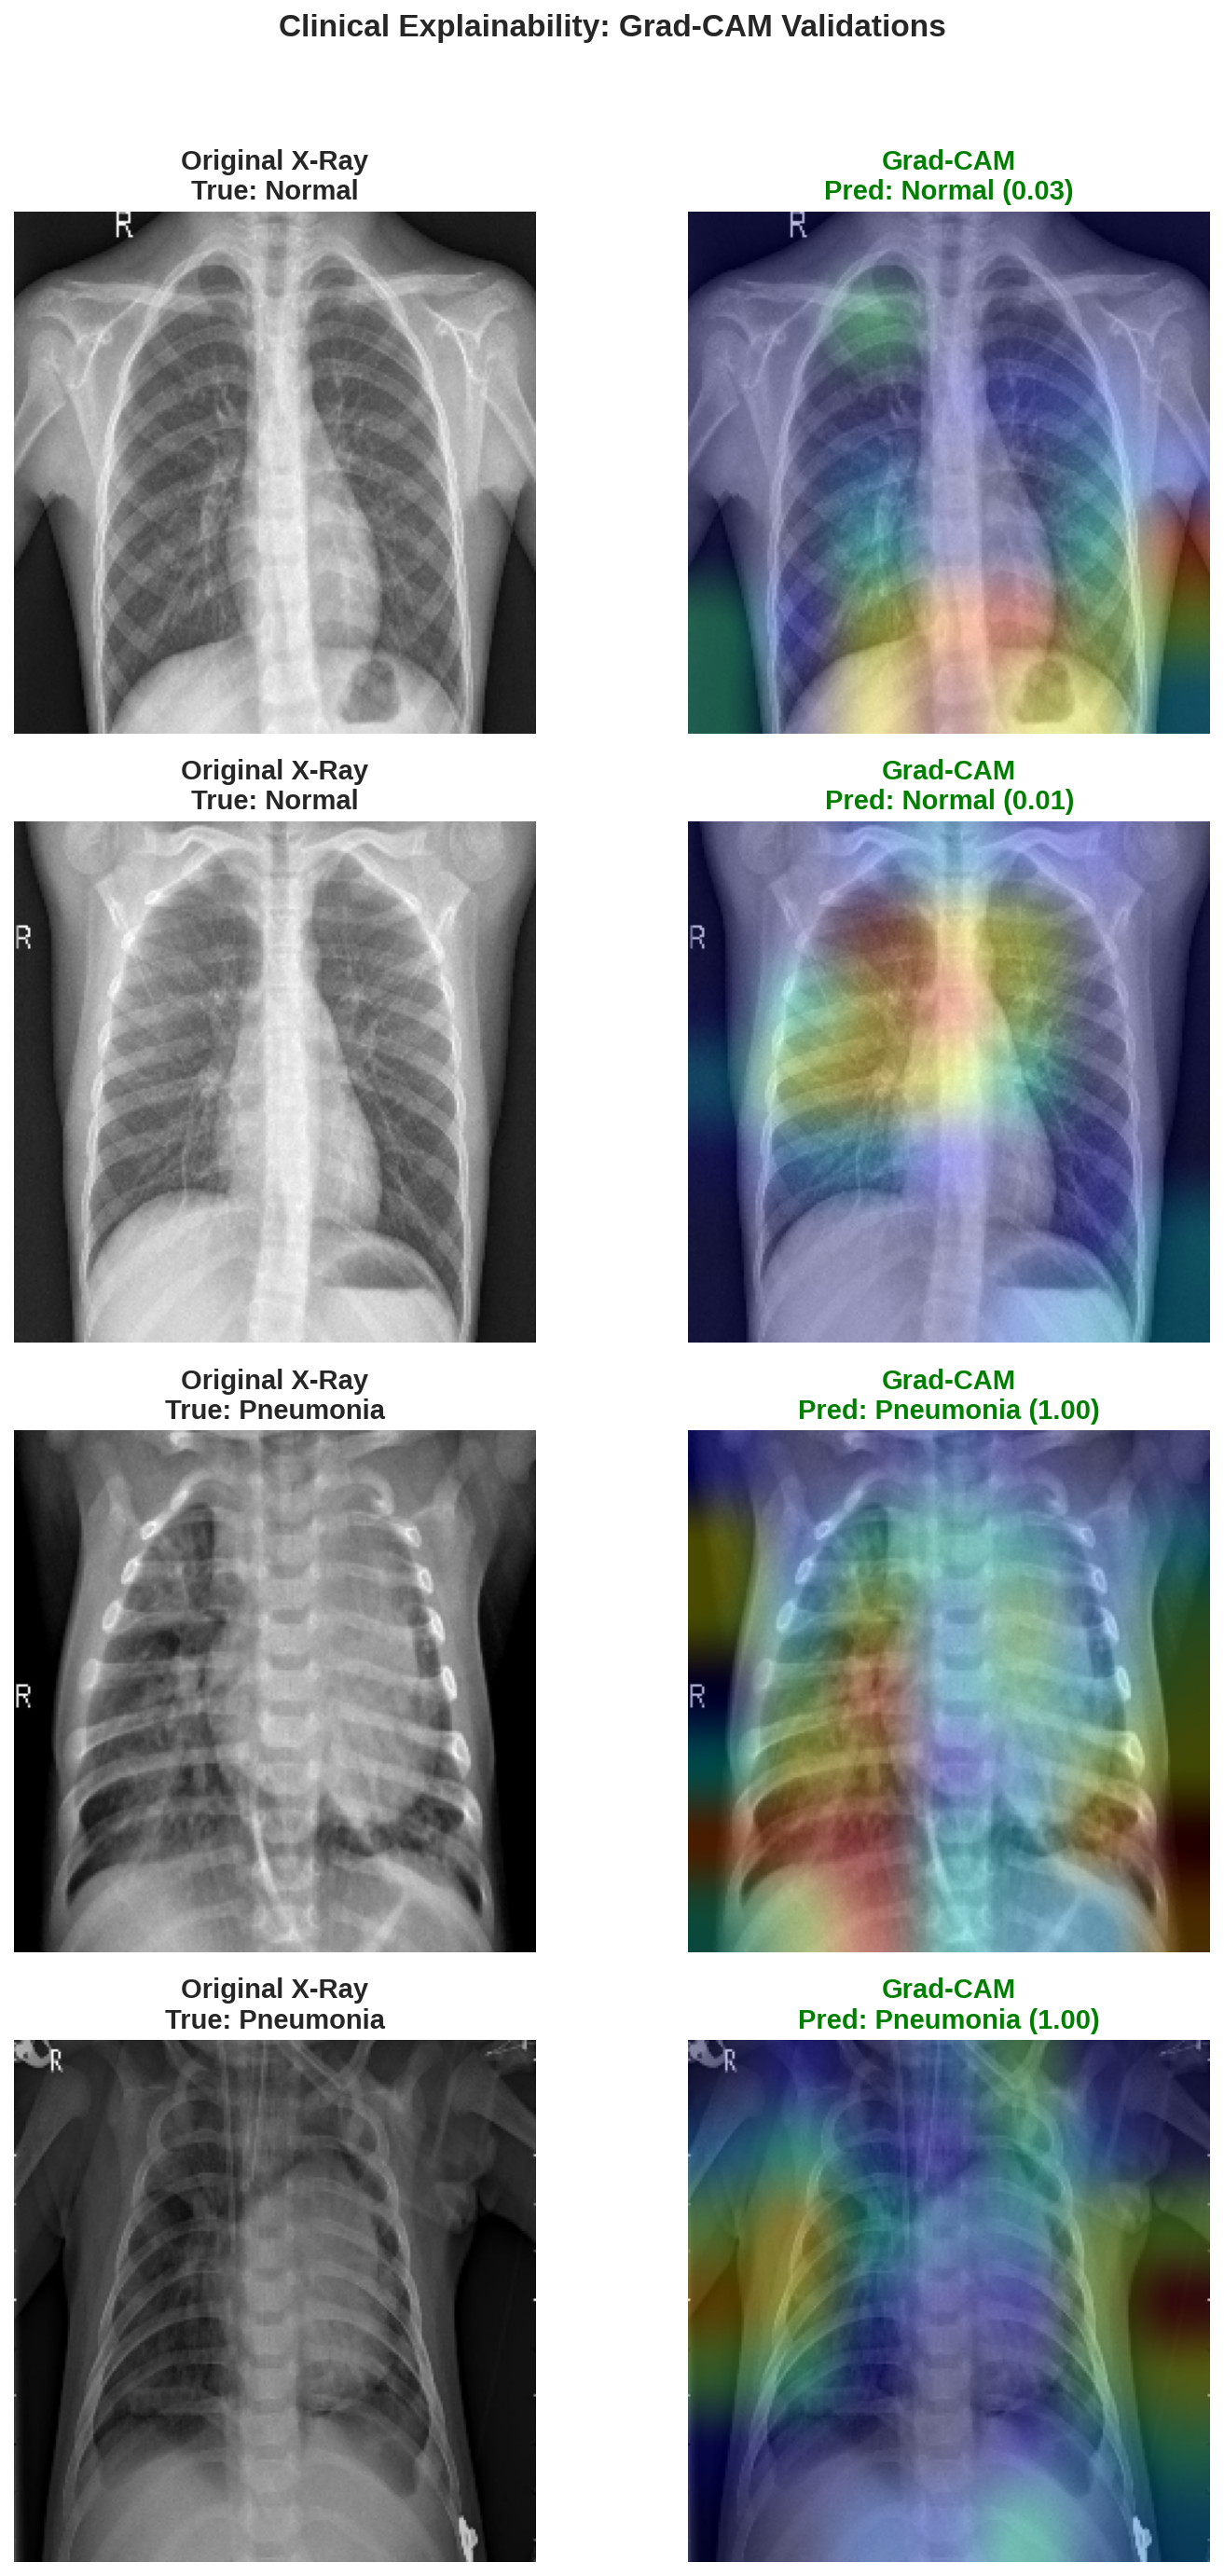

In [31]:
# ==============================================================================
# CELL 3: Clinical Case Extraction (True Positives & True Negatives)
# ==============================================================================

# 1. Prepare to find cases
found_tp = 0
found_tn = 0
tp_cases = []
tn_cases = []

# Get the correct layer dynamically
last_conv_name, base_model = get_last_conv_layer_name(model)
print(f"Targeting layer: {last_conv_name} for Grad-CAM.")

# 2. Iterate through test_ds until we find 2 TPs and 2 TNs
for images, labels in test_ds.unbatch().batch(1): # Process one by one
    if found_tp == 2 and found_tn == 2:
        break

    img_array = images.numpy()
    true_label = int(labels.numpy()[0])

    prob = model.predict(img_array, verbose=0)[0][0]
    pred_label = int(prob >= 0.5)

    if true_label == 1 and pred_label == 1 and found_tp < 2:
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_name, base_model)
        tp_cases.append((img_array[0], true_label, pred_label, prob, heatmap))
        found_tp += 1

    elif true_label == 0 and pred_label == 0 and found_tn < 2:
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_name, base_model)
        tn_cases.append((img_array[0], true_label, pred_label, prob, heatmap))
        found_tn += 1

# 3. Plot the 2x2 grid (4 clinical cases)
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
fig.suptitle("Clinical Explainability: Grad-CAM Validations", fontsize=16, fontweight='bold', y=0.92)

# Plot TNs
for i, case in enumerate(tn_cases):
    plot_gradcam_case(*case, axes[i])

# Plot TPs
for i, case in enumerate(tp_cases):
    plot_gradcam_case(*case, axes[i+2])

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# ==============================================================================
# ## 🚀 WEEK 10: FINAL DEPLOYMENT WITH GRADIO
# ==============================================================================

Let's deploy our Explainable AI model as a web-based clinical support tool.

In [32]:
!pip install -q gradio

In [33]:
import gradio as gr
import cv2
import numpy as np
from PIL import Image

def predict_and_explain(img_np):
    """
    Wrapper function for Gradio. Takes an image, preprocesses it, runs inference,
    and generates the Grad-CAM heatmap.
    """
    if img_np is None:
        return None, None, "⚠️ Please upload an image."

    # 1. Preprocess the image for our model (224x224, RGB, normalized 0-1)
    img_resized = cv2.resize(img_np, (224, 224))

    # Handle grayscale vs RGB inputs
    if len(img_resized.shape) == 2:
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
    elif img_resized.shape[-1] == 4:
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_RGBA2RGB)
    else:
        img_rgb = img_resized

    img_normalized = img_rgb.astype("float32") / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # 2. Get Prediction
    prob = model.predict(img_batch, verbose=0)[0][0]
    pred_class = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    confidence = prob if pred_class == "PNEUMONIA" else 1.0 - prob

    # Format results using Markdown
    color = "red" if pred_class == "PNEUMONIA" else "green"
    result_md = f"### Diagnosis: <span style='color:{color}'>{pred_class}</span>\n### Confidence: **{confidence*100:.2f}%**"

    # 3. Generate Grad-CAM Heatmap
    last_conv_name, base_model = get_last_conv_layer_name(model)
    heatmap = make_gradcam_heatmap(img_batch, model, last_conv_name, base_model)

    # 4. Overlay heatmap onto the original resized image
    superimposed_img = overlay_gradcam(img_normalized, heatmap, alpha=0.5)
    superimposed_np = np.array(superimposed_img)

    return img_rgb, superimposed_np, result_md

print("✓ Backend prediction function ready for deployment.")

✓ Backend prediction function ready for deployment.


In [34]:
# ==============================================================================
# Build and Launch the Gradio Blocks UI
# ==============================================================================

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    # Header
    gr.Markdown("<h1 style='text-align: center;'>🩺 Pediatric Pneumonia Detection Support System</h1>")
    gr.Markdown("<h3 style='text-align: center; color: gray;'>AI-Powered X-Ray Analysis with Grad-CAM Explainability</h3>")
    gr.Markdown("Upload a pediatric Chest X-Ray (CXR) image. The deep learning model will analyze the lungs for opacities and provide a diagnosis along with a visual heatmap explaining its decision.")

    with gr.Row():
        # Input Column
        with gr.Column(scale=1):
            img_input = gr.Image(label="Upload Raw Chest X-Ray")
            with gr.Row():
                clear_btn = gr.ClearButton(components=[img_input], value="🗑️ Clear")
                submit_btn = gr.Button("🔍 Analyze X-Ray", variant="primary")

        # Output Column
        with gr.Column(scale=1):
            diagnosis_output = gr.Markdown(label="Clinical Report")
            with gr.Row():
                img_original = gr.Image(label="Processed Image")
                img_heatmap = gr.Image(label="Grad-CAM Heatmap (Red = High Activation)")

    # Map the interface buttons to the backend function
    submit_btn.click(
        fn=predict_and_explain,
        inputs=img_input,
        outputs=[img_original, img_heatmap, diagnosis_output]
    )

# Launch the live demo with a public link
print("Launching Gradio Server...")
demo.launch(share=True, debug=False)

Launching Gradio Server...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://de58505472b862580f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
